In [2]:
import os
import re
import sys
import time
import getopt
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
sys.path.append("/home/users/mnergiz/softwares/licsar_extra/python")  # adjust as needed
import datetime as dt
from lics_tstools import load_licsbas_cumh5_as_xrda
from lics_tstools import generate_pmm_velocity
from lics_tstools import load_tif2xr

In [3]:
def spatial_reference_2d(da, reference, use_nearest=False):
    """
    Spatially reference a 2D DataArray (lat, lon) to a point.
    """
    # convert zeros to NaN
    da = da.where(da != 0)
    
    if use_nearest:
        ref_val = da.sel(lon=reference[0], lat=reference[1], method="nearest")
    else:
        ref_val = da.interp(lon=reference[0], lat=reference[1])

    # fallback if interpolation gives NaN
    if np.isnan(ref_val.values):
        ref_val = da.sel(lon=reference[0], lat=reference[1], method="nearest")

    return da - ref_val

def reference_ts_dataset(ds, reference, vars_to_ref=None, use_nearest=False, verbose=True):
    """
    Temporally reference each selected variable to the first epoch,
    then spatially reference each epoch to a given point.

    Parameters
    ----------
    ds : xarray.Dataset
        Dataset containing variables with dims including (time, lat, lon)
    reference : tuple
        (lon, lat)
    vars_to_ref : list[str]
        Variable names to process
    use_nearest : bool
        If True, use nearest pixel instead of interpolation
    verbose : bool
        Print which variables were processed/skipped

    Returns
    -------
    ds_ref : xarray.Dataset
        New referenced dataset
    """
    if vars_to_ref is None:
        vars_to_ref = ["cum", "iono", "tide", "sltd"]

    ds_ref = ds.copy()

    for v in vars_to_ref:
        if v not in ds.data_vars:
            if verbose:
                print(f"Skipping '{v}': not found in dataset")
            continue

        da = ds[v]

        # make sure required dimensions exist
        needed_dims = {"time", "lat", "lon"}
        if not needed_dims.issubset(set(da.dims)):
            if verbose:
                print(f"Skipping '{v}': dims are {da.dims}, need (time, lat, lon)")
            continue

        # 1) temporal reference to first epoch
        da_tref = da - da.isel(time=0)

        # 2) spatial reference to the chosen point, epoch by epoch
        if use_nearest:
            ref_ts = da_tref.sel(lon=reference[0], lat=reference[1], method="nearest")
        else:
            ref_ts = da_tref.interp(lon=reference[0], lat=reference[1])

        # if interpolation returns all-NaN, fall back to nearest
        if np.all(np.isnan(ref_ts.values)):
            if verbose:
                print(f"'{v}': interpolation returned all-NaN at reference, using nearest pixel")
            ref_ts = da_tref.sel(lon=reference[0], lat=reference[1], method="nearest")

        # subtract reference time series from every pixel
        ds_ref[v] = da_tref - ref_ts

        if verbose:
            print(f"Referenced '{v}'")

    return ds_ref

In [4]:
frame="021D_05266_252525"
sbovl=False
if sbovl:
    path=f"/gws/ssde/j25a/nceo_geohazards/vol2/LiCS/temp/insar_proc/mnergizci/1.postseismic_dataset_backup_04122025/sbois/{frame}"
else:
    path=f"/gws/ssde/j25a/nceo_geohazards/vol2/LiCS/temp/insar_proc/mnergizci/1.postseismic_dataset_backup_04122025/ranges/{frame}"
TS_folder = next(
    p for p in Path(path).iterdir()
    if p.is_dir() and p.name.startswith("TS_")
)
GEOC_folder = os.path.join(os.path.dirname(os.path.normpath(TS_folder)), "GEOCml10GACOS")
os.environ["LiCSAR_public"] = "/gws/ssde/j25a/nceo_geohazards/vol1/public/LiCSAR_products.public/"
cumfile=f"{TS_folder}/cum.h5"
cumfiltfile=f"{TS_folder}/cum_filt.h5"
cum = load_licsbas_cumh5_as_xrda(cumfile)
cum_filt = load_licsbas_cumh5_as_xrda(cumfiltfile)

#plotting and reference points
reference=(37, 35.5) #lon lat
point1=(36.7, 38.2) #lon lat

#years calculation
years = (cum.time[-1] - cum.time[0]) / np.timedelta64(1, 'D') / 365.25
print(float(years))

1.8726899383983573


In [5]:
vars_to_ref = ["cum", "iono", "tide", "sltd"]

cum_ref = reference_ts_dataset(
    cum,
    reference=reference,
    vars_to_ref=vars_to_ref,
    use_nearest=True,
    verbose=True
)

cum_filt_ref = reference_ts_dataset(
    cum_filt,
    reference=reference,
    vars_to_ref=vars_to_ref,
    use_nearest=True,
    verbose=True
)

Referenced 'cum'
Referenced 'iono'
Referenced 'tide'
Referenced 'sltd'
Referenced 'cum'
Skipping 'iono': not found in dataset
Skipping 'tide': not found in dataset
Skipping 'sltd': not found in dataset


In [6]:
##plate motion and interseismic effect
#plate motion
vlos_eurasia = generate_pmm_velocity(frame, 'Eurasia', 'GEOC', azi=sbovl)
# #reshape
vlos_eurasia_reshaped=vlos_eurasia.interp_like(cum.vel)
plate_motion_cumulative = vlos_eurasia_reshaped * years

#interseismic model
ve_gnss_nc='/gws/ssde/j25a/nceo_geohazards/vol1/projects/COMET/mnergizci/1.second_paper/interseismic/decomp3d.nc'
vn_gnss_nc='/gws/ssde/j25a/nceo_geohazards/vol1/projects/COMET/mnergizci/1.second_paper/interseismic/velmap_insars29_sbois0_scalar.nc'

#ENU unit vectors
if sbovl:
    E_unit=load_tif2xr(f'{path}/{frame}.E.azi.geo.tif')
    N_unit=load_tif2xr(f'{path}/{frame}.N.azi.geo.tif')
    # azimuth has no vertical sensitivity
    U_unit = xr.zeros_like(E_unit)
else:
    E_unit=load_tif2xr(f'{path}/{frame}.E.geo.tif')
    N_unit=load_tif2xr(f'{path}/{frame}.N.geo.tif')
    U_unit=load_tif2xr(f'{path}/{frame}.U.geo.tif')

#load interseismic model
ve_gnss= xr.load_dataset(ve_gnss_nc).Ve
vn_gnss= xr.load_dataset(vn_gnss_nc).Vn

##reshape
ve_gnss_reshaped=ve_gnss.interp_like(E_unit)
vn_gnss_reshaped=vn_gnss.interp_like(E_unit)

interseismic_velo = ve_gnss_reshaped * E_unit + vn_gnss_reshaped * N_unit
interseismic_velo_cumulative = interseismic_velo*years

##reference
plate_motion_cumulative_ref = spatial_reference_2d(
    plate_motion_cumulative, reference, use_nearest=True
)
plate_motion_cumulative_ref=plate_motion_cumulative_ref.interp_like(cum_filt_ref.cum[-1])


interseismic_velo_cumulative_ref = spatial_reference_2d(
    interseismic_velo_cumulative, reference, use_nearest=True
)
interseismic_velo_cumulative_ref=interseismic_velo_cumulative_ref.interp_like(cum_filt_ref.cum[-1])


assume a spheroidal Earth as defined in WGS84
Interpolating the plate velocity ENU vectors to the original frame resolution
Calculating the plate motion velocity in LOS (please check the sign here)


In [7]:
##
uncorrected_cum = (
    cum_filt_ref.cum.isel(time=-1)
    + plate_motion_cumulative_ref
    + interseismic_velo_cumulative_ref
    + cum_ref.iono.isel(time=-1)
    + cum_ref.tide.isel(time=-1)
    + cum_ref.sltd.isel(time=-1)
)
corrected_cum=cum_filt_ref.cum[-1]
topog=cum_ref.sltd[-1]
iono=cum_ref.iono[-1]
tide=cum_ref.tide[-1]

DEM already exists!


getfattr: Removing leading '/' from absolute path names
getfattr: Removing leading '/' from absolute path names
getfattr: Removing leading '/' from absolute path names
getfattr: Removing leading '/' from absolute path names
getfattr: Removing leading '/' from absolute path names
getfattr: Removing leading '/' from absolute path names
getfattr: Removing leading '/' from absolute path names
getfattr: Removing leading '/' from absolute path names
getfattr: Removing leading '/' from absolute path names
getfattr: Removing leading '/' from absolute path names
getfattr: Removing leading '/' from absolute path names
getfattr: Removing leading '/' from absolute path names


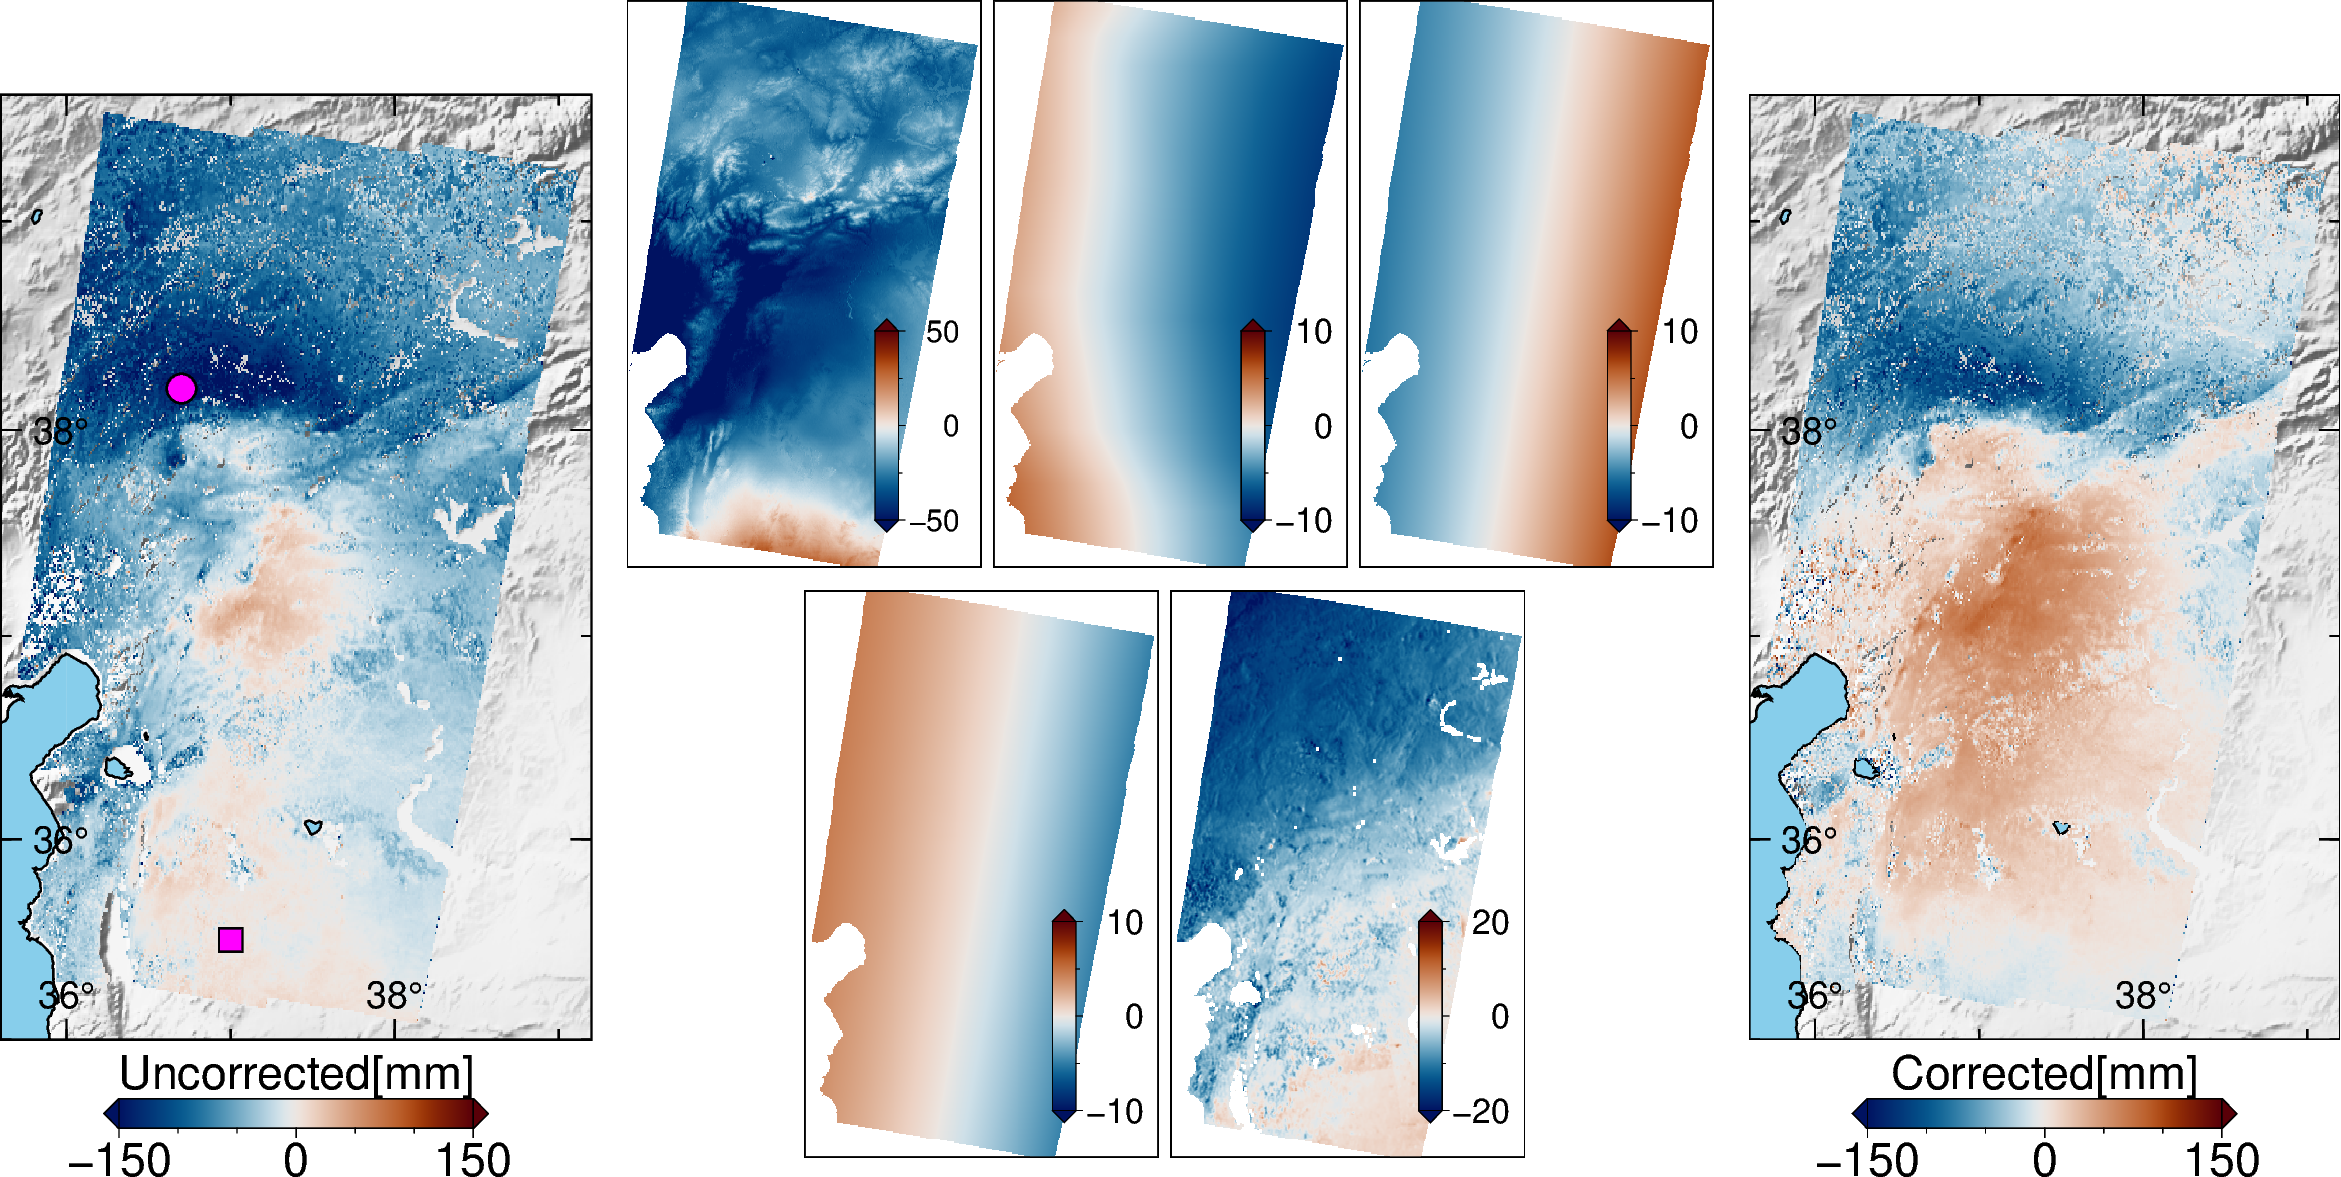

In [8]:
import pygmt
##DEM file
dem_file='earth_relief_fullAHB_30s.nc'
batchdir = os.environ.get("BATCH_CACHE_DIR")
dem = os.path.join(batchdir, dem_file)
#####
# DEM downloading
if not os.path.exists(dem):
    print('DEM is downloading please wait! After downloading, the process will be faster!')
    try:
        lonmin_lamb = 1  # degrees East
        lonmax_lamb = 80
        latmin_lamb = 25
        latmax_lamb = 60
        RR_used = [lonmin_lamb, lonmax_lamb, latmin_lamb, latmax_lamb]
        dem_resolution='30s'
        # Download the earth relief data and save it to a file
        grid = pygmt.datasets.load_earth_relief(resolution=dem_resolution, region=RR_used)
        # Saving the grid to a NetCDF file
        grid.to_netcdf(dem)
        print(f"Data successfully downloaded and saved to {dem}")
    except Exception as e:
        print(f"An error occurred: {e}")
else:
    print(f'DEM already exists!')

##fault file
# GEMS_dir='/scratch/eemne/GEMS'
# fault_file=f'{GEMS_dir}/actives/TR_active_faults.shp'

#plot region
plot_region = [35.6, 39.2, 35, 39.6]
#####
fig = pygmt.Figure()
pygmt.config(
    MAP_FRAME_TYPE="plain",
    FONT_ANNOT_PRIMARY="20p,Helvetica,black",   # longitude ticks
    FONT_LABEL="20p,Helvetica,black",       # axis labels
    FORMAT_GEO_MAP='D',
    MAP_FRAME_PEN="0.5p,black",  # 2-point thick black frame line
    MAP_DEFAULT_PEN="0.5p,black",
    # MAP_TICK_PEN_PRIMARY="1p",
    # MAP_TICK_LENGTH_PRIMARY="5p",
    MAP_TICK_LENGTH="5p"
)
## Figure a --plotting Uncorrected deformation
#Plot background DEM
fig.basemap(projection="M5c", region=plot_region, frame=['WSne'])
pygmt.makecpt(cmap="gray", series=[-200, 10000, 3000], continuous=True, reverse=True)
fig.grdimage(grid=dem,cmap=True,region=plot_region,shading=True,frame=False)
fig.coast(shorelines="black", water="skyblue")
#plotting uncorrected deformation
cmap = pygmt.makecpt(cmap="vik", series=[-150, 150, 1], continuous=True)
fig.grdimage(grid=uncorrected_cum, cmap=cmap, region=plot_region, nan_transparent=True)

###colorbar
pygmt.config(MAP_FRAME_TYPE="plain", FONT_ANNOT_PRIMARY="25p,Helvetica,black", FONT_LABEL="25p,Helvetica, black")
fig.colorbar(
    frame='a150f50+lUncorrected[mm]',  # Label for the color bar
    cmap=True,
    position="JBC+o0c/0.5c+w3c/0.25c+ml+h+e"
    # truncate=[vmin, vmax],  # Color bar starts at 0 (excluding ocean DEM values)
    # box="+gwhite@50"
)

# plotting reference points
# circle for point1
fig.plot(
    x=point1[0],
    y=point1[1],
    style="c0.25c",      # circle, diameter 0.25 cm
    fill="magenta1",
    pen="0.5p,black"
)

# rectangle for reference point
fig.plot(
    x=reference[0],
    y=reference[1],
    style="r0.20c/0.20c",  # rectangle width/height
    fill="magenta1",
    pen="0.5p,black"
)

#last basemap
pygmt.config(MAP_FRAME_TYPE="inside", FONT_ANNOT="9p,Helvetica,black")
fig.basemap(projection="M5c", region=plot_region, frame=["x2f1","y2f1",'WSne'])

#Figure b --plotting troposhere
fig.shift_origin(xshift='5.3c', yshift='4c')
#Plot background DEM
fig.basemap(projection="M3c", region=plot_region, frame=['wsne'])
#plotting uncorrected deformation
cmap = pygmt.makecpt(cmap="vik", series=[-50, 50, 1], continuous=True)
fig.grdimage(grid=topog, cmap=cmap, region=plot_region, nan_transparent=True)

###colorbar
pygmt.config(MAP_FRAME_TYPE="plain", FONT_ANNOT_PRIMARY="22p,Helvetica,black", FONT_LABEL="20p,Helvetica, black")
fig.colorbar(
    frame='a50f25',  # Label for the color bar
    cmap=True,
    position="JMR+o-0.9c/-1.2c+w1.6c/0.2c+ml+e"
    # truncate=[vmin, vmax],  # Color bar starts at 0 (excluding ocean DEM values)
    # box="+gwhite@50"
)

#last basemap
pygmt.config(MAP_FRAME_TYPE="inside", FONT_ANNOT="9p,Helvetica,black")
fig.basemap(projection="M3c", region=plot_region, frame=["x200f100","y200f100",'WSne'])

#Figure c --plotting iono
fig.shift_origin(xshift='3.1c')
#Plot background DEM
fig.basemap(projection="M3c", region=plot_region, frame=['wsne'])
#plotting uncorrected deformation
cmap = pygmt.makecpt(cmap="vik", series=[-10, 10, 1], continuous=True)
fig.grdimage(grid=iono, cmap=cmap, region=plot_region, nan_transparent=True)

###colorbar
pygmt.config(MAP_FRAME_TYPE="plain", FONT_ANNOT_PRIMARY="25p,Helvetica,black", FONT_LABEL="25p,Helvetica, black")
fig.colorbar(
    frame='a10f5',  # Label for the color bar
    cmap=True,
    position="JMR+o-0.9c/-1.2c+w1.6c/0.2c+ml+e"
    # truncate=[vmin, vmax],  # Color bar starts at 0 (excluding ocean DEM values)
    # box="+gwhite@50"
)

#last basemap
pygmt.config(MAP_FRAME_TYPE="inside", FONT_ANNOT="9p,Helvetica,black")
fig.basemap(projection="M3c", region=plot_region, frame=["x200f100","y200f100",'WSne'])

#Figure d --plotting tide
fig.shift_origin(xshift='3.1c')
#Plot background DEM
fig.basemap(projection="M3c", region=plot_region, frame=['wsne'])
#plotting uncorrected deformation
cmap = pygmt.makecpt(cmap="vik", series=[-10, 10, 1], continuous=True)
fig.grdimage(grid=tide, cmap=cmap, region=plot_region, nan_transparent=True)

###colorbar
pygmt.config(MAP_FRAME_TYPE="plain", FONT_ANNOT_PRIMARY="25p,Helvetica,black", FONT_LABEL="25p,Helvetica, black")
fig.colorbar(
    frame='a10f5',  # Label for the color bar
    cmap=True,
    position="JMR+o-0.9c/-1.2c+w1.6c/0.2c+ml+e"
    # truncate=[vmin, vmax],  # Color bar starts at 0 (excluding ocean DEM values)
    # box="+gwhite@50"
)

#last basemap
pygmt.config(MAP_FRAME_TYPE="inside", FONT_ANNOT="9p,Helvetica,black")
fig.basemap(projection="M3c", region=plot_region, frame=["x200f100","y200f100",'WSne'])

#Figure e --plate tide
fig.shift_origin(xshift='-4.7c', yshift='-5c')
#Plot background DEM
fig.basemap(projection="M3c", region=plot_region, frame=['wsne'])
#plotting uncorrected deformation
cmap = pygmt.makecpt(cmap="vik", series=[-10, 10, 1], continuous=True)
fig.grdimage(grid=plate_motion_cumulative_ref , cmap=cmap, region=plot_region, nan_transparent=True)

###colorbar
pygmt.config(MAP_FRAME_TYPE="plain", FONT_ANNOT_PRIMARY="25p,Helvetica,black", FONT_LABEL="25p,Helvetica, black")
fig.colorbar(
    frame='a10f5',  # Label for the color bar
    cmap=True,
    position="JMR+o-0.9c/-1.2c+w1.6c/0.2c+ml+e"
    # truncate=[vmin, vmax],  # Color bar starts at 0 (excluding ocean DEM values)
    # box="+gwhite@50"
)

#last basemap
pygmt.config(MAP_FRAME_TYPE="inside", FONT_ANNOT="9p,Helvetica,black")
fig.basemap(projection="M3c", region=plot_region, frame=["x200f100","y200f100",'WSne'])

#Figure f --interseismic
fig.shift_origin(xshift='3.1c')
#Plot background DEM
fig.basemap(projection="M3c", region=plot_region, frame=['wsne'])
#plotting uncorrected deformation
cmap = pygmt.makecpt(cmap="vik", series=[-20, 20, 1], continuous=True)
fig.grdimage(grid=interseismic_velo_cumulative_ref , cmap=cmap, region=plot_region, nan_transparent=True)

###colorbar
pygmt.config(MAP_FRAME_TYPE="plain", FONT_ANNOT_PRIMARY="25p,Helvetica,black", FONT_LABEL="25p,Helvetica, black")
fig.colorbar(
    frame='a20f10',  # Label for the color bar
    cmap=True,
    position="JMR+o-0.9c/-1.2c+w1.6c/0.2c+ml+e"
    # truncate=[vmin, vmax],  # Color bar starts at 0 (excluding ocean DEM values)
    # box="+gwhite@50"
)

#last basemap
pygmt.config(MAP_FRAME_TYPE="inside", FONT_ANNOT="9p,Helvetica,black")
fig.basemap(projection="M3c", region=plot_region, frame=["x200f100","y200f100",'WSne'])

#Figure g --corrected
fig.shift_origin(xshift='4.9c', yshift="1c")
#Plot background DEM
fig.basemap(projection="M5c", region=plot_region, frame=['WSne'])
pygmt.makecpt(cmap="gray", series=[-200, 10000, 3000], continuous=True, reverse=True)
fig.grdimage(grid=dem,cmap=True,region=plot_region,shading=True,frame=False)
fig.coast(shorelines="black", water="skyblue")
#plotting uncorrected deformation
cmap = pygmt.makecpt(cmap="vik", series=[-150, 150, 1], continuous=True)
fig.grdimage(grid=corrected_cum , cmap=cmap, region=plot_region, nan_transparent=True)

###colorbar
pygmt.config(MAP_FRAME_TYPE="plain", FONT_ANNOT_PRIMARY="25p,Helvetica,black", FONT_LABEL="25p,Helvetica, black")
fig.colorbar(
    frame='a150f50+lCorrected[mm]',  # Label for the color bar
    cmap=True,
    position="JBC+o0c/0.5c+w3c/0.25c+ml+h+e"
    # truncate=[vmin, vmax],  # Color bar starts at 0 (excluding ocean DEM values)
    # box="+gwhite@50"
)

#last basemap
pygmt.config(MAP_FRAME_TYPE="inside", FONT_ANNOT="9p,Helvetica,black")
fig.basemap(projection="M5c", region=plot_region, frame=["x2f1","y2f1",'WSne'])


fig.savefig("Figure3_cumulative_corrections_range_raw.png")
fig.show()


In [9]:
# extract time series at point1
tide_ts = cum_ref["tide"].interp(lon=point1[0], lat=point1[1], method="nearest")
iono_ts = cum_ref["iono"].interp(lon=point1[0], lat=point1[1], method="nearest")
sltd_ts = cum_ref["sltd"].interp(lon=point1[0], lat=point1[1], method="nearest")
cum_ts  = cum_ref["cum"].interp(lon=point1[0], lat=point1[1], method="nearest")
cum_filt_ts  = cum_filt_ref["cum"].interp(lon=point1[0], lat=point1[1], method="nearest")
time = cum_ref.time

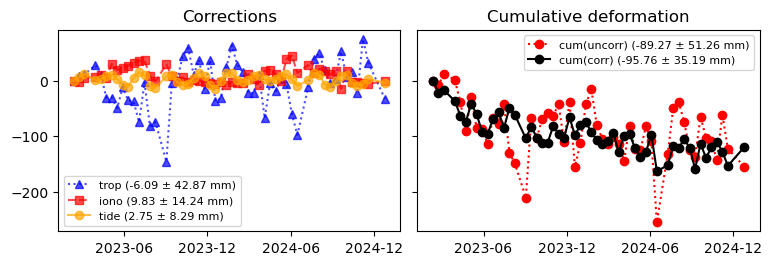

In [13]:

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
# plt.rcParams.update({
#     "font.family": "serif",
#     "font.serif": ["Times New Roman"],   # common journal style
#     "font.size": 9,                      # base size
#     "axes.labelsize": 9,
#     "axes.titlesize": 10,
#     "xtick.labelsize": 8,
#     "ytick.labelsize": 8,
#     "legend.fontsize": 8,
#     "axes.linewidth": 0.8,
#     "lines.linewidth": 1.2,
#     "lines.markersize": 4,
# })

cm = 1 / 2.54  # inches per cm

fig, ax = plt.subplots(1, 2, figsize=(20*cm, 7*cm), sharex=True, sharey=True)

##statistics
#mean
uncor_cum_ts = cum_ts + tide_ts + iono_ts + sltd_ts
mean_trop = np.nanmean(sltd_ts)
mean_iono = np.nanmean(iono_ts)
mean_tide = np.nanmean(tide_ts)
mean_uncor_cum = np.nanmean(uncor_cum_ts)
mean_cum = np.nanmean(cum_ts)


#std
std_trop = np.nanstd(sltd_ts)
std_iono = np.nanstd(iono_ts)
std_tide = np.nanstd(tide_ts)
std_uncor_cum = np.nanstd(uncor_cum_ts)
std_cum = np.nanstd(cum_ts)



# ---- Left panel: corrections ----
plt.rcParams["legend.fontsize"] = 8
ax[0].plot(time, sltd_ts, color="blue", marker="^", linestyle=":", alpha=0.7, label=f"trop ({mean_trop:.2f} ± {std_trop:.2f} mm)")
ax[0].plot(time, iono_ts, color="red", marker="s", linestyle="--", alpha=0.7, label=f"iono ({mean_iono:.2f} ± {std_iono:.2f} mm)")
ax[0].plot(time, tide_ts, color="orange", marker="o", linestyle="-", alpha=0.7, label=f"tide ({mean_tide:.2f} ± {std_tide:.2f} mm)")

# ax[0].set_ylabel("Displacement (mm)")
ax[0].set_title("Corrections")
ax[0].legend()

# ---- Right panel: cumulative deformation ----
ax[1].plot(time, uncor_cum_ts, color="red", marker="o", linestyle=":", label=f"cum-uncorr ({mean_uncor_cum:.2f} ± {std_uncor_cum:.2f} mm)")
ax[1].plot(time, cum_ts, color="black", marker="o", linestyle="-", label=f"cum-corr ({mean_cum:.2f} ± {std_cum:.2f} mm)")

ax[1].set_title("Cumulative deformation")
ax[1].legend()

# hide y tick labels on second plot
ax[1].tick_params(labelleft=False)

# ----- Sparse x-axis ticks -----
locator = mdates.MonthLocator(interval=6)   # every 3 months
formatter = mdates.DateFormatter('%Y-%m')

for a in ax:
    a.xaxis.set_major_locator(locator)
    a.xaxis.set_major_formatter(formatter)

# # shared x label
# fig.supxlabel("Time")

plt.tight_layout()
# reduce space between panels
fig.subplots_adjust(wspace=0.05)
plt.savefig("Figure3_cumulative_corrections_range_raw_time_series.png", dpi=300)
plt.show()